# Phase 1: Data Collection and Structurally Faithful Preprocessing

This notebook pulls the raw financial datasets (FinQA for fine-tuning, FinanceBench for evaluation) and applies heuristic layout parsing.
It produces structured Markdown tables, generates CoT prompts, and includes comprehensive EDA with multiple visualizations.

## Environment Setup

Install or update data processing, visualization, and tokenization libraries.

In [1]:
%pip -q install "datasets>=2.18.0" "pandas>=2.2.0" "numpy>=1.26.0" "matplotlib>=3.8.0" "seaborn>=0.13.0" "tqdm>=4.66.0" "transformers>=4.40.0" "wordcloud>=1.9.0"

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount("/content/drive", force_remount=False)

# Define search locations for the project root
candidate_roots = [
    Path("/content/drive/MyDrive/FinGEO-SLM"),
    Path("/content/FinGEO-SLM"),
    Path.cwd()
]

# Identify PROJECT_ROOT by checking for the 'data/finQA' directory structure
PROJECT_ROOT = Path.cwd()
for p in candidate_roots:
    if p.exists() and (p / "data" / "finQA").exists():
        PROJECT_ROOT = p
        break

os.chdir(PROJECT_ROOT)
print(f"Project root set to: {PROJECT_ROOT}")

def project_path(*parts):
    return str(PROJECT_ROOT.joinpath(*parts))

# Verify the specific file exists
finqa_train = project_path("data", "finQA", "train.json")
if os.path.exists(finqa_train):
    print(f"Confirmed: Found train.json at {finqa_train}")
else:
    print(f"Warning: train.json not found at {finqa_train}. Please check the folder structure.")

Project root set to: /Users/uzmanarfan/Documents/FinGEO-SLM
Confirmed: Found train.json at /Users/uzmanarfan/Documents/FinGEO-SLM/data/finQA/train.json


In [ ]:
# Google Drive Integration - Auto-mount on Colab
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    try:
        from google.colab import drive
        print("📁 Mounting Google Drive...")
        drive.mount('/content/drive', force_remount=False)
        print("✓ Google Drive mounted successfully at /content/drive")
        print("✓ Your files will be accessible at: /content/drive/MyDrive/FinGEO-SLM/")
    except Exception as e:
        print(f"⚠ Warning: Could not mount Google Drive: {e}")
        print("  Continuing without Drive integration...")
else:
    print("ℹ Running locally or on Vast.ai - skipping Google Drive mount")
    print("  (Google Drive integration is only active on Colab)")

## Google Drive Integration (Colab Only)

This cell automatically mounts Google Drive when running on Colab, enabling seamless data persistence across sessions.

In [3]:
import json
import textwrap
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset, Dataset
from transformers import AutoTokenizer
from tqdm.auto import tqdm
from collections import Counter
from wordcloud import WordCloud

# Set consistent color scheme
sns.set_theme(style="whitegrid")
COLORS = ['#2a9d8f', '#e76f51', '#f4a261', '#e9c46a', '#264653']
sns.set_palette(sns.color_palette(COLORS))

# Set matplotlib defaults
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100
plt.rcParams['font.size'] = 10

/Users/uzmanarfan/.pyenv/versions/3.12.9/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Loading

Load FinQA from local storage and FinanceBench from Hugging Face Hub.

In [4]:
print("Loading datasets...")
finqa_path = project_path("data", "finQA", "train.json")

try:
    with open(finqa_path, "r", encoding="utf-8") as f:
        raw_finqa_data = json.load(f)
except FileNotFoundError as exc:
    raise FileNotFoundError(f"Missing FinQA file at {finqa_path}") from exc
except json.JSONDecodeError as exc:
    raise ValueError("FinQA JSON is malformed") from exc

cleaned_finqa = []
for item in tqdm(raw_finqa_data, desc="Cleaning FinQA", unit="example"):
    qa_data = item.get("qa", {})
    cleaned_finqa.append(
        {
            "pre_text": item.get("pre_text", []),
            "post_text": item.get("post_text", []),
            "table": item.get("table", []),
            "question": qa_data.get("question", ""),
            "answer": str(qa_data.get("answer", "")),
            "exe_list": qa_data.get("exe_list", qa_data.get("steps", [])),
        }
    )

finqa_dataset = Dataset.from_list(cleaned_finqa)

try:
    financebench_dataset = load_dataset("PatronusAI/financebench", split="train")
except Exception as exc:
    raise RuntimeError("Failed to load FinanceBench from the Hub") from exc

print(f"\nDataset Sizes:")
print(f"  FinQA: {len(finqa_dataset):,} samples")
print(f"  FinanceBench: {len(financebench_dataset):,} samples")

Loading datasets...


Cleaning FinQA: 100%|██████████| 6251/6251 [00:00<00:00, 435676.80example/s]



Dataset Sizes:
  FinQA: 6,251 samples
  FinanceBench: 150 samples


## Data Exploration and Statistics

Extract key metrics from the datasets for visualization.

In [5]:
# Extract data for analysis
print("Extracting data for analysis...")

# Question and answer lengths
question_lengths = [len(item['question']) for item in finqa_dataset]
answer_lengths = [len(item['answer']) for item in finqa_dataset]

# Pre and post text lengths
pre_text_lengths = [len(' '.join(item['pre_text'])) for item in finqa_dataset]
post_text_lengths = [len(' '.join(item['post_text'])) for item in finqa_dataset]

# Table sizes (rows x columns)
table_sizes = []
for item in finqa_dataset:
    table = item.get('table', [])
    if table and len(table) > 0:
        rows = len(table)
        cols = len(table[0]) if table[0] else 0
        table_sizes.append((rows, cols))
    else:
        table_sizes.append((0, 0))

# Reasoning steps count
reasoning_steps_count = []
for item in finqa_dataset:
    exe_list = item.get('exe_list', [])
    if isinstance(exe_list, list):
        reasoning_steps_count.append(len(exe_list))
    else:
        reasoning_steps_count.append(0)

# Answer type classification (numeric vs text)
def is_numeric_answer(answer):
    """Check if answer is primarily numeric."""
    # Remove common symbols and check if what remains is mostly numeric
    cleaned = re.sub(r'[%$,\s]', '', answer)
    if not cleaned:
        return False
    # Check if at least 50% of characters are digits
    digit_count = sum(c.isdigit() for c in cleaned)
    return digit_count / len(cleaned) > 0.5

answer_types = ['Numeric' if is_numeric_answer(item['answer']) else 'Text' 
                for item in finqa_dataset]

# Word frequency for questions
stop_words = {'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 
              'of', 'with', 'by', 'from', 'as', 'is', 'was', 'are', 'were', 'be',
              'been', 'being', 'have', 'has', 'had', 'do', 'does', 'did', 'will',
              'would', 'should', 'could', 'may', 'might', 'must', 'can', 'what',
              'which', 'who', 'when', 'where', 'why', 'how', 'that', 'this', 'these',
              'those', 'it', 'its', 'they', 'them', 'their'}

all_question_words = []
for item in finqa_dataset:
    words = re.findall(r'\b[a-z]+\b', item['question'].lower())
    all_question_words.extend([w for w in words if w not in stop_words and len(w) > 2])

word_freq = Counter(all_question_words)
top_words = word_freq.most_common(20)

print(f"\nData extraction complete!")
print(f"  Analyzed {len(finqa_dataset):,} samples")
print(f"  Found {len(word_freq):,} unique words in questions")

Extracting data for analysis...

Data extraction complete!
  Analyzed 6,251 samples
  Found 2,740 unique words in questions


## Prompt Formatting Functions

Utilities for parsing tables and formatting CoT prompts.

In [6]:
def format_table_to_markdown(table_data):
    """Converts raw 2D array financial tables into structurally faithful Markdown with NaN handling."""
    if not table_data or len(table_data) == 0:
        return ""
    try:
        headers = table_data[0]
        rows = table_data[1:]
        df = pd.DataFrame(rows, columns=headers)
        # Improvement: Fill empty/dash values with 0 or N/A for consistency
        df = df.replace(['', '-', 'n/a', 'None'], '0')
        return df.to_markdown(index=False)
    except Exception:
        return str(table_data)

def format_cot_prompt(example, tokenizer=None, max_tokens=3500):
    """Formats FinQA into a strict CoT prompt with smart truncation."""
    pre_text = " ".join(example.get("pre_text", []))
    post_text = " ".join(example.get("post_text", []))
    table_context = format_table_to_markdown(example.get("table", []))
    question = example.get("question", "")
    answer = example.get("answer", "")
    exe_list = example.get("exe_list", [])

    # Validation: Skip junk data
    if not question or len(question) < 5:
        return {"formatted_prompt": None}

    reasoning_steps = " -> ".join([
        f"{s.get('op', '')}({s.get('arg1', '')}, {s.get('arg2', '')}) = {s.get('res', '')}"
        for s in exe_list
    ]) if isinstance(exe_list, list) and exe_list and isinstance(exe_list[0], dict) else str(exe_list)

    instruction = "You are a highly accurate financial AI. Use the context and table to answer step-by-step."

    def build_p(pre, post):
        return f"[INST] {instruction}\nContext:\n{pre}\n{post}\n\nFinancial Table:\n{table_context}\n\nQuestion: {question}\n[/INST]\nLet's think step by step.\nReasoning: {reasoning_steps}\nFinal Answer: {answer}"

    full_prompt = build_p(pre_text, post_text)

    # Improvement: Smart Truncation
    if tokenizer and len(tokenizer.encode(full_prompt)) > max_tokens:
        # Priority: Table and Question are kept; pre/post text are truncated
        pre_text = pre_text[:500] + "..."
        post_text = post_text[:500] + "..."
        full_prompt = build_p(pre_text, post_text)

    return {"formatted_prompt": full_prompt}

## Apply Formatting

Apply CoT formatting to the dataset with smart truncation.

In [7]:
print("Applying improved CoT formatting...")
tokenizer = AutoTokenizer.from_pretrained("microsoft/Phi-3-mini-4k-instruct")

# Map with tokenizer passed in for smart truncation
finqa_cot_dataset = finqa_dataset.map(
    lambda x: format_cot_prompt(x, tokenizer=tokenizer),
    desc="Formatting with Smart Truncation"
)

# Filter out any None results from validation
finqa_cot_dataset = finqa_cot_dataset.filter(lambda x: x['formatted_prompt'] is not None)

print(f"Improved preprocessing complete. Final count: {len(finqa_cot_dataset):,}")

Applying improved CoT formatting...


Filter: 100%|██████████| 6251/6251 [00:00<00:00, 30238.26 examples/s]

Improved preprocessing complete. Final count: 6,251


## Visualizations

Comprehensive visual analysis of the dataset characteristics.

### 1. Dataset Size Comparison

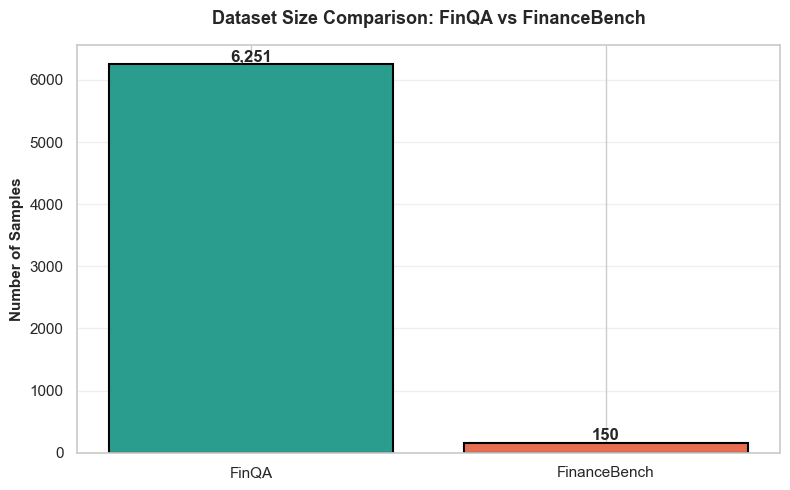

FinQA is 41.7x larger than FinanceBench


In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

datasets = ['FinQA', 'FinanceBench']
sizes = [len(finqa_dataset), len(financebench_dataset)]

bars = ax.bar(datasets, sizes, color=COLORS[:2], edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_ylabel('Number of Samples', fontsize=11, fontweight='bold')
ax.set_title('Dataset Size Comparison: FinQA vs FinanceBench', fontsize=13, fontweight='bold', pad=15)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"FinQA is {len(finqa_dataset)/len(financebench_dataset):.1f}x larger than FinanceBench")

### 2. Question Length Distribution

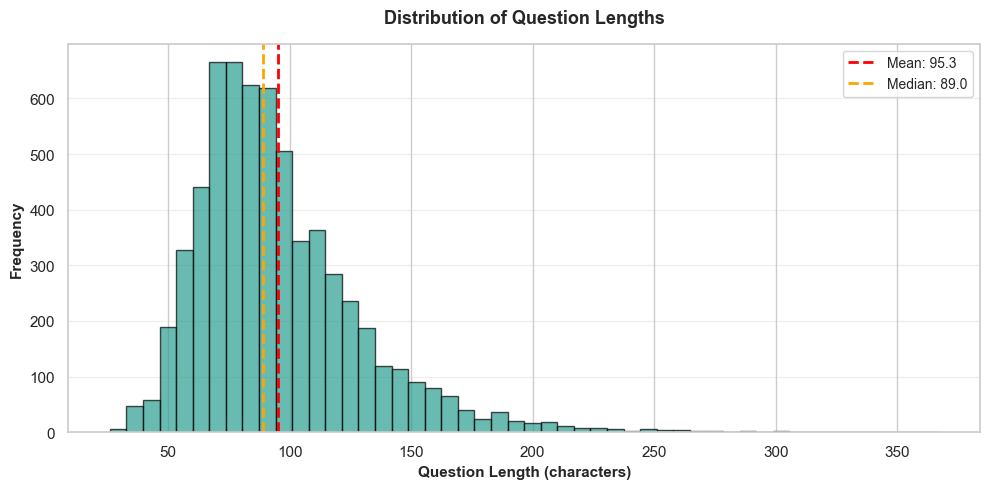

Question Length Statistics:
  Min: 26 | Max: 367
  Mean: 95.3 | Median: 89.0
  Std Dev: 34.4


In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(question_lengths, bins=50, color=COLORS[0], edgecolor='black', alpha=0.7)

# Add statistics
mean_len = np.mean(question_lengths)
median_len = np.median(question_lengths)
ax.axvline(mean_len, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_len:.1f}')
ax.axvline(median_len, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_len:.1f}')

ax.set_xlabel('Question Length (characters)', fontsize=11, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax.set_title('Distribution of Question Lengths', fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Question Length Statistics:")
print(f"  Min: {min(question_lengths)} | Max: {max(question_lengths)}")
print(f"  Mean: {mean_len:.1f} | Median: {median_len:.1f}")
print(f"  Std Dev: {np.std(question_lengths):.1f}")

### 3. Answer Length Distribution

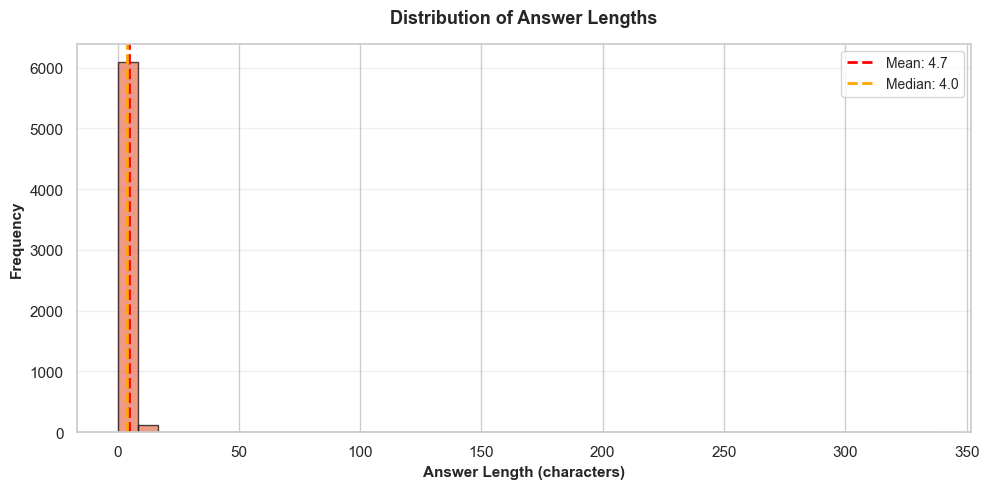

Answer Length Statistics:
  Min: 0 | Max: 335
  Mean: 4.7 | Median: 4.0
  Std Dev: 7.6


In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(answer_lengths, bins=40, color=COLORS[1], edgecolor='black', alpha=0.7)

# Add statistics
mean_len = np.mean(answer_lengths)
median_len = np.median(answer_lengths)
ax.axvline(mean_len, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_len:.1f}')
ax.axvline(median_len, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_len:.1f}')

ax.set_xlabel('Answer Length (characters)', fontsize=11, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax.set_title('Distribution of Answer Lengths', fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Answer Length Statistics:")
print(f"  Min: {min(answer_lengths)} | Max: {max(answer_lengths)}")
print(f"  Mean: {mean_len:.1f} | Median: {median_len:.1f}")
print(f"  Std Dev: {np.std(answer_lengths):.1f}")

### 4. Table Size Visualization (Rows × Columns)

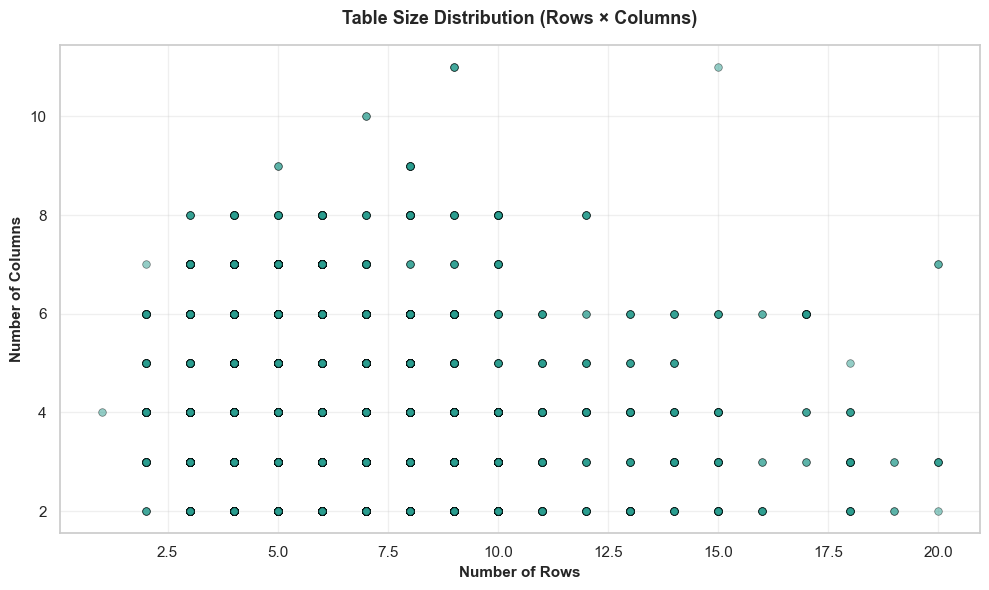

Table Size Statistics:
  Tables with data: 6,251 (100.0%)
  Average rows: 6.3 | Average columns: 3.8
  Max rows: 20 | Max columns: 11


In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

rows = [size[0] for size in table_sizes if size[0] > 0]
cols = [size[1] for size in table_sizes if size[0] > 0]

# Create scatter plot with alpha for overlapping points
scatter = ax.scatter(rows, cols, alpha=0.5, c=COLORS[0], s=30, edgecolor='black', linewidth=0.5)

ax.set_xlabel('Number of Rows', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of Columns', fontsize=11, fontweight='bold')
ax.set_title('Table Size Distribution (Rows × Columns)', fontsize=13, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Table Size Statistics:")
print(f"  Tables with data: {len(rows):,} ({len(rows)/len(table_sizes)*100:.1f}%)")
print(f"  Average rows: {np.mean(rows):.1f} | Average columns: {np.mean(cols):.1f}")
print(f"  Max rows: {max(rows)} | Max columns: {max(cols)}")

### 5. Reasoning Steps Count Distribution

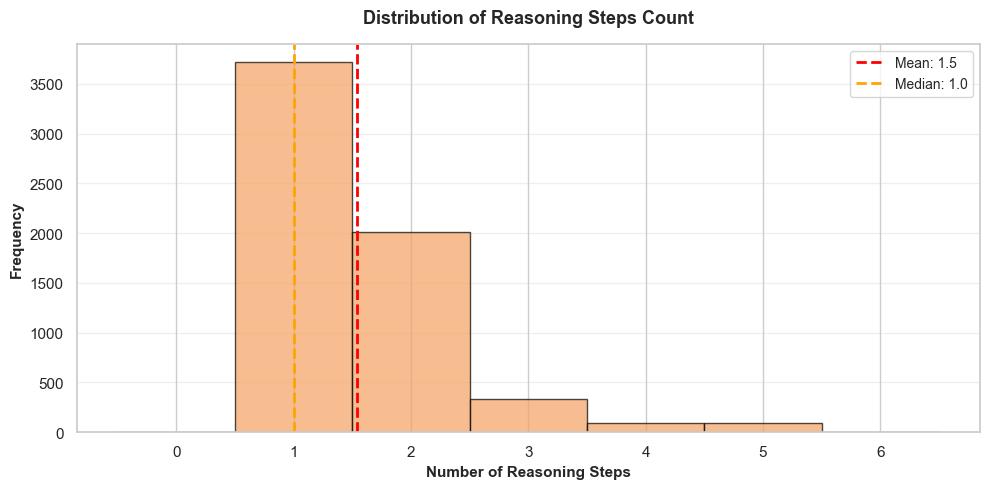

Reasoning Steps Statistics:
  Min: 1 | Max: 6
  Mean: 1.54 | Median: 1.0
  Std Dev: 0.80


In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(reasoning_steps_count, bins=range(0, max(reasoning_steps_count)+2), 
        color=COLORS[2], edgecolor='black', alpha=0.7, align='left')

# Add statistics
mean_steps = np.mean(reasoning_steps_count)
median_steps = np.median(reasoning_steps_count)
ax.axvline(mean_steps, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_steps:.1f}')
ax.axvline(median_steps, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_steps:.1f}')

ax.set_xlabel('Number of Reasoning Steps', fontsize=11, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax.set_title('Distribution of Reasoning Steps Count', fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Reasoning Steps Statistics:")
print(f"  Min: {min(reasoning_steps_count)} | Max: {max(reasoning_steps_count)}")
print(f"  Mean: {mean_steps:.2f} | Median: {median_steps:.1f}")
print(f"  Std Dev: {np.std(reasoning_steps_count):.2f}")

### 6. Pre/Post Text Length Comparison

/var/folders/ft/w1m9fjt15kq_n08blxds8tn80000gn/T/ipykernel_33598/1252428990.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True,


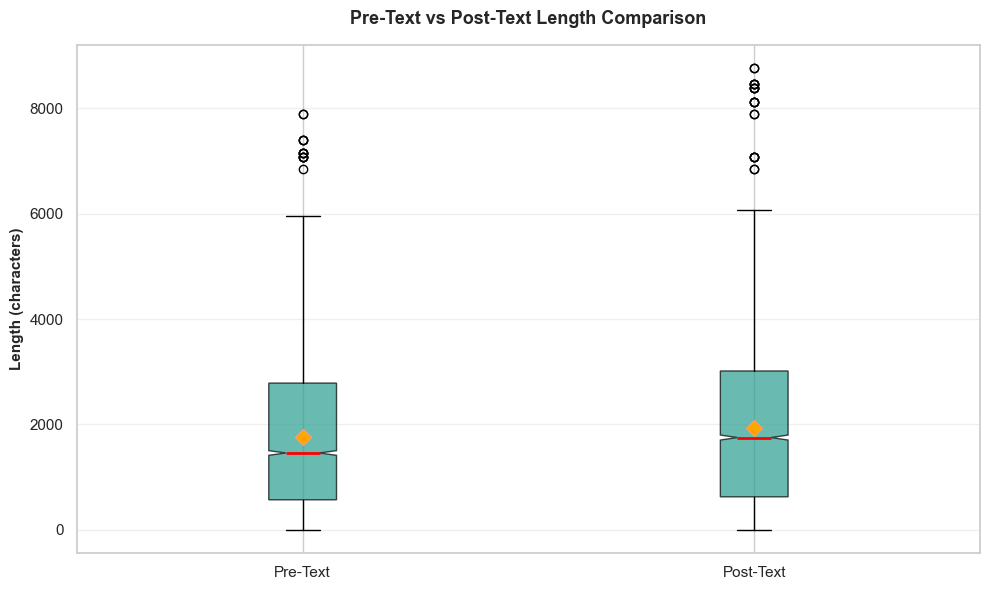

Pre-Text Statistics:
  Mean: 1770.1 | Median: 1458.0

Post-Text Statistics:
  Mean: 1925.3 | Median: 1751.0


In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data for box plots
data_to_plot = [pre_text_lengths, post_text_lengths]
labels = ['Pre-Text', 'Post-Text']

bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True,
                notch=True, showmeans=True,
                boxprops=dict(facecolor=COLORS[0], alpha=0.7),
                medianprops=dict(color='red', linewidth=2),
                meanprops=dict(marker='D', markerfacecolor='orange', markersize=8))

ax.set_ylabel('Length (characters)', fontsize=11, fontweight='bold')
ax.set_title('Pre-Text vs Post-Text Length Comparison', fontsize=13, fontweight='bold', pad=15)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Pre-Text Statistics:")
print(f"  Mean: {np.mean(pre_text_lengths):.1f} | Median: {np.median(pre_text_lengths):.1f}")
print(f"\nPost-Text Statistics:")
print(f"  Mean: {np.mean(post_text_lengths):.1f} | Median: {np.median(post_text_lengths):.1f}")

### 7. Top Question Words

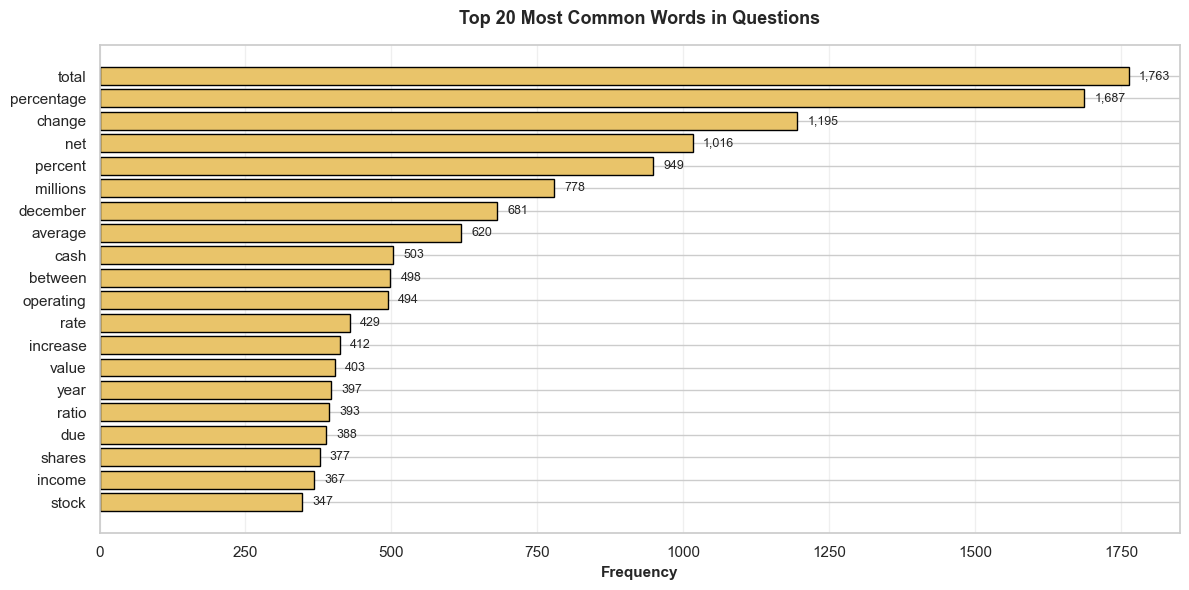


Top 5 most common words:
  total: 1,763
  percentage: 1,687
  change: 1,195
  net: 1,016
  percent: 949


In [14]:
fig, ax = plt.subplots(figsize=(12, 6))

words, counts = zip(*top_words)
y_pos = np.arange(len(words))

bars = ax.barh(y_pos, counts, color=COLORS[3], edgecolor='black', linewidth=1)

# Add value labels
for i, (bar, count) in enumerate(zip(bars, counts)):
    ax.text(count + max(counts)*0.01, i, f'{count:,}', 
            va='center', fontsize=9)

ax.set_yticks(y_pos)
ax.set_yticklabels(words)
ax.invert_yaxis()
ax.set_xlabel('Frequency', fontsize=11, fontweight='bold')
ax.set_title('Top 20 Most Common Words in Questions', fontsize=13, fontweight='bold', pad=15)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTop 5 most common words:")
for word, count in top_words[:5]:
    print(f"  {word}: {count:,}")

### 8. Answer Type Distribution (Numeric vs Text)

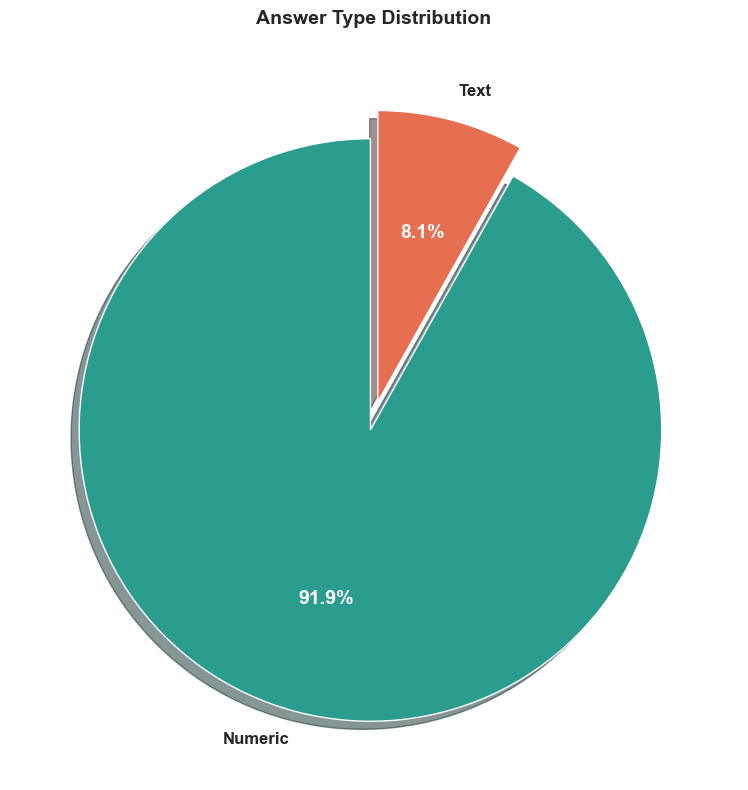

Answer Type Breakdown:
  Numeric: 5,742 (91.9%)
  Text: 509 (8.1%)


In [15]:
fig, ax = plt.subplots(figsize=(8, 8))

type_counts = Counter(answer_types)
labels = list(type_counts.keys())
sizes = list(type_counts.values())
colors_pie = [COLORS[0], COLORS[1]]

wedges, texts, autotexts = ax.pie(sizes, labels=labels, colors=colors_pie, autopct='%1.1f%%',
                                    startangle=90, explode=(0.05, 0.05),
                                    shadow=True, textprops={'fontsize': 12, 'fontweight': 'bold'})

# Make percentage text more visible
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(14)

ax.set_title('Answer Type Distribution', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print(f"Answer Type Breakdown:")
for label, size in zip(labels, sizes):
    print(f"  {label}: {size:,} ({size/sum(sizes)*100:.1f}%)")

### 9. Enhanced Token Length Visualization with Percentiles

Computing token lengths for formatted prompts...


Computing token lengths: 100%|██████████| 2000/2000 [00:00<00:00, 4708.87 examples/s]


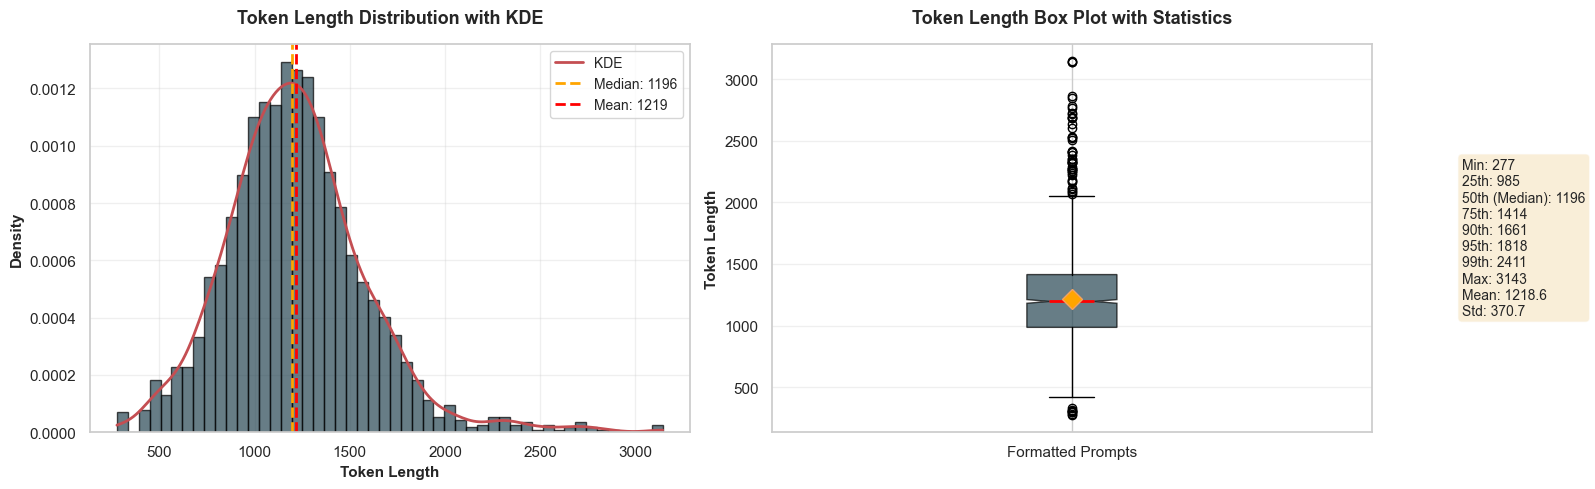


Token Length Statistics (Sample of 2,000):
  Min: 277 | Max: 3143
  Mean: 1218.64 | Median: 1196
  Std Dev: 370.67

Percentiles:
  25th: 985 | 75th: 1414
  90th: 1661 | 95th: 1818 | 99th: 2411


In [16]:
try:
    print("Computing token lengths for formatted prompts...")
    sample_size = min(2000, len(finqa_cot_dataset))
    eda_sample = finqa_cot_dataset.select(range(sample_size))

    def add_token_length(batch):
        tokenized = tokenizer(batch["formatted_prompt"], add_special_tokens=False)
        return {"token_length": [len(ids) for ids in tokenized["input_ids"]]}

    eda_with_len = eda_sample.map(add_token_length, batched=True, desc="Computing token lengths")
    lengths = eda_with_len["token_length"]

    # Calculate percentiles
    p25 = np.percentile(lengths, 25)
    p50 = np.percentile(lengths, 50)
    p75 = np.percentile(lengths, 75)
    p90 = np.percentile(lengths, 90)
    p95 = np.percentile(lengths, 95)
    p99 = np.percentile(lengths, 99)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    # Histogram with KDE
    ax1.hist(lengths, bins=50, color=COLORS[4], edgecolor='black', alpha=0.7, density=True)
    
    # Add KDE
    from scipy import stats
    density = stats.gaussian_kde(lengths)
    x_range = np.linspace(min(lengths), max(lengths), 200)
    ax1.plot(x_range, density(x_range), 'r-', linewidth=2, label='KDE')
    
    ax1.axvline(p50, color='orange', linestyle='--', linewidth=2, label=f'Median: {p50:.0f}')
    ax1.axvline(np.mean(lengths), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(lengths):.0f}')
    
    ax1.set_xlabel('Token Length', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Density', fontsize=11, fontweight='bold')
    ax1.set_title('Token Length Distribution with KDE', fontsize=13, fontweight='bold', pad=15)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)

    # Box plot with percentiles
    bp = ax2.boxplot([lengths], vert=True, patch_artist=True, notch=True, showmeans=True,
                      boxprops=dict(facecolor=COLORS[4], alpha=0.7),
                      medianprops=dict(color='red', linewidth=2),
                      meanprops=dict(marker='D', markerfacecolor='orange', markersize=10))
    
    # Add percentile annotations
    percentiles_text = [
        f"Min: {min(lengths)}",
        f"25th: {p25:.0f}",
        f"50th (Median): {p50:.0f}",
        f"75th: {p75:.0f}",
        f"90th: {p90:.0f}",
        f"95th: {p95:.0f}",
        f"99th: {p99:.0f}",
        f"Max: {max(lengths)}",
        f"Mean: {np.mean(lengths):.1f}",
        f"Std: {np.std(lengths):.1f}"
    ]
    
    ax2.text(1.15, 0.5, '\n'.join(percentiles_text), 
             transform=ax2.transAxes, fontsize=10,
             verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax2.set_ylabel('Token Length', fontsize=11, fontweight='bold')
    ax2.set_title('Token Length Box Plot with Statistics', fontsize=13, fontweight='bold', pad=15)
    ax2.set_xticklabels(['Formatted Prompts'])
    ax2.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\nToken Length Statistics (Sample of {sample_size:,}):")
    print(f"  Min: {min(lengths)} | Max: {max(lengths)}")
    print(f"  Mean: {np.mean(lengths):.2f} | Median: {p50:.0f}")
    print(f"  Std Dev: {np.std(lengths):.2f}")
    print(f"\nPercentiles:")
    print(f"  25th: {p25:.0f} | 75th: {p75:.0f}")
    print(f"  90th: {p90:.0f} | 95th: {p95:.0f} | 99th: {p99:.0f}")
    
except Exception as exc:
    print(f"Token length analysis failed: {exc}")

### 10. Sample Prompt Display with Enhanced Formatting

In [17]:
import pandas as pd
from IPython.display import display, HTML

# Display first 5 samples in a formatted table
display_df = pd.DataFrame(finqa_cot_dataset.select(range(5)))

print("="*100)
print("SAMPLE DATA FROM PREPROCESSED DATASET")
print("="*100)
print(f"\nShowing first 5 rows of {len(finqa_cot_dataset):,} total samples")
print("\nColumns: {}".format(', '.join(display_df.columns)))
print("\n" + "-"*100)

display(display_df[['question', 'answer']].head())

print("\n" + "="*100)
print("DETAILED SAMPLE PROMPT EXAMPLE")
print("="*100)

sample_prompt = finqa_cot_dataset[0]["formatted_prompt"]
sample_question = finqa_cot_dataset[0]["question"]
sample_answer = finqa_cot_dataset[0]["answer"]

print(f"\nQuestion: {sample_question}")
print(f"Answer: {sample_answer}")
print(f"\nToken Count: {len(tokenizer.encode(sample_prompt))}")
print(f"Character Count: {len(sample_prompt)}")

print("\n" + "-"*100)
print("FULL FORMATTED PROMPT:")
print("-"*100 + "\n")

# Format prompt with better wrapping
wrapped_prompt = textwrap.fill(sample_prompt, width=100, 
                               break_long_words=False, 
                               break_on_hyphens=False)
print(wrapped_prompt)

print("\n" + "="*100 + "\n")

SAMPLE DATA FROM PREPROCESSED DATASET

Showing first 5 rows of 6,251 total samples

Columns: pre_text, post_text, table, question, answer, exe_list, formatted_prompt

----------------------------------------------------------------------------------------------------


,question,answer
0,what is the the interest expense in 2009?,380
1,"during the 2012 year , did the equity awards i...",
2,what was the total operating expenses in 2018 ...,41932
3,what percentage of total cash and investments ...,53%
4,what is the growth rate in net revenue in 2008?,-3.2%



DETAILED SAMPLE PROMPT EXAMPLE

Question: what is the the interest expense in 2009?
Answer: 380

Token Count: 1114
Character Count: 4245

----------------------------------------------------------------------------------------------------
FULL FORMATTED PROMPT:
----------------------------------------------------------------------------------------------------

[INST] You are a highly accurate financial AI. Use the context and table to answer step-by-step.
Context: interest rate to a variable interest rate based on the three-month libor plus 2.05% ( 2.05
% ) ( 2.34% ( 2.34 % ) as of october 31 , 2009 ) . if libor changes by 100 basis points , our annual
interest expense would change by $ 3.8 million . foreign currency exposure as more fully described
in note 2i . in the notes to consolidated financial statements contained in item 8 of this annual
report on form 10-k , we regularly hedge our non-u.s . dollar-based exposures by entering into
forward foreign currency exchange contracts .

## Save Processed Data

Save the formatted dataset to disk for use in training.

In [18]:
os.makedirs(project_path("processed_data"), exist_ok=True)
finqa_cot_dataset.save_to_disk(project_path("processed_data", "finqa_cot"))

print(f"Dataset saved successfully!")
print(f"  Location: {project_path('processed_data', 'finqa_cot')}")
print(f"  Total samples: {len(finqa_cot_dataset):,}")

Saving the dataset (1/1 shards): 100%|██████████| 6251/6251 [00:00<00:00, 111892.26 examples/s]

Dataset saved successfully!
  Location: /Users/uzmanarfan/Documents/FinGEO-SLM/processed_data/finqa_cot
  Total samples: 6,251


In [ ]:
# Save processed_data to Google Drive (Colab only)
import shutil
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    try:
        # Define paths
        local_processed = Path(project_path("processed_data"))
        drive_base = Path("/content/drive/MyDrive/FinGEO-SLM")
        drive_processed = drive_base / "processed_data"
        
        print("📤 Copying processed_data to Google Drive...")
        print(f"   Source: {local_processed}")
        print(f"   Destination: {drive_processed}")
        
        # Create Drive directory structure if needed
        drive_base.mkdir(parents=True, exist_ok=True)
        
        # Check if source exists
        if not local_processed.exists():
            print(f"⚠ Warning: Source directory not found: {local_processed}")
            print("  Nothing to copy to Google Drive")
        else:
            # Remove old data if exists
            if drive_processed.exists():
                print("  Removing old processed_data from Drive...")
                shutil.rmtree(drive_processed)
            
            # Copy to Drive
            shutil.copytree(local_processed, drive_processed)
            
            # Verify
            copied_files = list(drive_processed.rglob("*"))
            print(f"✓ Successfully copied processed_data to Google Drive")
            print(f"✓ Total files copied: {len(copied_files)}")
            print(f"✓ Location: {drive_processed}")
            print()
            print("ℹ This data is now persistent and will be available in:")
            print("  - Notebook 02 (Training)")
            print("  - Notebook 03 (Evaluation)")
            
    except Exception as e:
        print(f"⚠ Error copying to Google Drive: {e}")
        print("  Your data is still saved locally at:", project_path("processed_data"))
else:
    print("ℹ Running locally or on Vast.ai - skipping Google Drive backup")
    print(f"  Data saved locally at: {project_path('processed_data')}")

## Save to Google Drive (Colab Only)

Automatically copy processed data to Google Drive for persistence and access in training notebooks.

## Validation

Run strict checks to confirm preprocessing artifacts and schema were produced correctly.

In [19]:
print("Running validation checks...\n")

# Check 1: Dataset not empty
assert len(finqa_dataset) > 0, "FinQA dataset is empty"
print("✓ FinQA dataset loaded successfully")

assert len(financebench_dataset) > 0, "FinanceBench dataset is empty"
print("✓ FinanceBench dataset loaded successfully")

# Check 2: Formatted dataset not empty
assert len(finqa_cot_dataset) > 0, "Formatted FinQA dataset is empty"
print("✓ Formatted FinQA dataset created successfully")

# Check 3: Required columns exist
assert "formatted_prompt" in finqa_cot_dataset.column_names, "formatted_prompt column missing"
print("✓ formatted_prompt column exists")

# Check 4: Data was saved
assert os.path.exists(project_path("processed_data", "finqa_cot")), "processed_data/finqa_cot not found"
print("✓ Processed data saved to disk")

# Check 5: Sample data quality
sample = finqa_cot_dataset[0]
assert sample['formatted_prompt'] is not None, "Sample prompt is None"
assert len(sample['formatted_prompt']) > 0, "Sample prompt is empty"
print("✓ Sample data quality check passed")

# Check 6: All required fields present
required_fields = ['pre_text', 'post_text', 'table', 'question', 'answer', 'exe_list', 'formatted_prompt']
for field in required_fields:
    assert field in finqa_cot_dataset.column_names, f"Required field '{field}' missing"
print(f"✓ All {len(required_fields)} required fields present")

print("\n" + "="*80)
print("VALIDATION COMPLETE: Phase 1 notebook executed end-to-end successfully!")
print("="*80)

print(f"\nFinal Statistics:")
print(f"  Total samples processed: {len(finqa_cot_dataset):,}")
print(f"  Samples with numeric answers: {answer_types.count('Numeric'):,} ({answer_types.count('Numeric')/len(answer_types)*100:.1f}%)")
print(f"  Samples with text answers: {answer_types.count('Text'):,} ({answer_types.count('Text')/len(answer_types)*100:.1f}%)")
print(f"  Average reasoning steps: {np.mean(reasoning_steps_count):.2f}")
print(f"  Average question length: {np.mean(question_lengths):.1f} characters")
print(f"  Average answer length: {np.mean(answer_lengths):.1f} characters")

Running validation checks...

✓ FinQA dataset loaded successfully
✓ FinanceBench dataset loaded successfully
✓ Formatted FinQA dataset created successfully
✓ formatted_prompt column exists
✓ Processed data saved to disk
✓ Sample data quality check passed
✓ All 7 required fields present

VALIDATION COMPLETE: Phase 1 notebook executed end-to-end successfully!

Final Statistics:
  Total samples processed: 6,251
  Samples with numeric answers: 5,742 (91.9%)
  Samples with text answers: 509 (8.1%)
  Average reasoning steps: 1.54
  Average question length: 95.3 characters
  Average answer length: 4.7 characters
